[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/milioe/casos-ia-ibero-diplomado/blob/main/Modulo%204%3A%20NLP/09_Word2Vec.ipynb)


# Word2Vec — convertir palabras en números **con sentido**

En el notebook anterior vimos cómo entrenar redes neuronales y cómo razonan en probabilidades con softmax + cross-entropy. Aquí usamos **exactamente esa misma maquinaria** para resolver un problema clásico de NLP: convertir palabras en vectores numéricos que capturen significado.

La idea, en una frase: **entrenamos una red Skip-gram (centro → palabras del contexto); los pesos que aprende son los embeddings**. Eso es Word2Vec.

Vamos en tres partes:

1. **Parte 1 — A mano con Keras**: una red mínima de 4 entradas, 2 neuronas ocultas y 4 salidas. Sirve para *ver* cómo nacen los embeddings con Skip-gram y ventana 1.
2. **Parte 2 — Conceptual**: CBOW (la alternativa a Skip-gram) y negative sampling, los detalles que hacen viable a Word2Vec en la práctica.
3. **Parte 3 — Corpus mediano**: las mismas 50 frases de soporte fintech, Skip-gram con ventana 2, embeddings de 50 dimensiones y visualización con PCA por temas.


## Setup — instalar todo lo que vamos a usar

`gensim` es una librería clásica de NLP que tiene Word2Vec implementado de forma muy eficiente. La usaremos en la parte 3.


In [1]:
# Descomenta si te falta alguno (Colab ya trae casi todo)
%pip install -q numpy matplotlib pandas scikit-learn tensorflow gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})


def pares_skipgram(tokens, window=1):
    """Skip-gram: un ejemplo (centro, contexto) por cada vecina en la ventana."""
    pares = []
    for i, centro in enumerate(tokens):
        for j in range(max(0, i - window), min(len(tokens), i + window + 1)):
            if j == i:
                continue
            pares.append((centro, tokens[j]))
    return pares


WINDOW = 1  # Parte 1: una palabra a la izquierda y una a la derecha del centro


# Parte 1 — Word2Vec a mano

Vamos a construir la red **más sencilla posible** para que se vea claramente qué está pasando.


## 1 — El problema: cómo convertir palabras en números

En el notebook de TF-IDF vimos algo así:

```
"no puedo pagar"
"no puedo transferir"
```

Para nosotros, **`pagar` y `transferir` son parecidas**: las dos hablan de mover dinero. Pero TF-IDF las trata como columnas independientes — no sabe que comparten significado.

Si quisiéramos meter esas frases a una red neuronal, lo más ingenuo sería **asignar un número aleatorio a cada palabra**:

| Palabra | Número |
|---|---|
| pagar | 0.3 |
| transferir | -7.2 |

Aunque significan cosas parecidas, los números no se parecen en nada. La red tendría que **aprender por separado** cómo manejar cada una.

**Lo que queremos:** que palabras parecidas (que aparecen en contextos parecidos) tengan **números parecidos**. Y de paso, que cada palabra tenga **varios números** (un vector), para capturar distintos matices.

¿Cómo conseguir esos números? Aquí está la idea genial: **dejamos que una red neuronal los descubra sola**.


## 2 — La idea de Word2Vec en una frase

> **Entrena una red Skip-gram: dada la palabra del centro, predice sus vecinas. Los pesos resultantes son los embeddings.**

Si dos palabras (por ejemplo `pagar` y `transferir`) aparecen **rodeadas de las mismas palabras vecinas**, la red, para predecir esos contextos, va a tener que asignarles **vectores parecidos**. Esos vectores son el embedding.

La arquitectura sigue siendo **un softmax sobre el vocabulario por paso**; lo que cambia es que generamos **varios pares** por palabra centro (izquierda y derecha), no solo “la siguiente palabra”.

## 3 — Corpus de juguete (sólo 2 frases)

Para que veamos clarísimo cómo nacen los embeddings, vamos a entrenar la red con **dos frases minúsculas** de estructura idéntica:

> "no puedo pagar"
> "no puedo transferir"

`pagar` y `transferir` aparecen en exactamente el mismo contexto (después de `puedo`). La hipótesis: la red les debería asignar vectores parecidos.


In [3]:
corpus = [
    "no puedo pagar",
    "no puedo transferir",
]

for i, frase in enumerate(corpus, 1):
    print(f"{i}. {frase}")


1. no puedo pagar
2. no puedo transferir


## 4 — Tokenizar y construir el vocabulario

Cada frase la separamos en palabras y juntamos todas las únicas. Como sólo hay 2 frases muy chiquitas, el vocabulario tendrá **4 palabras**: `no`, `puedo`, `pagar`, `transferir`. Esos serán los **4 inputs** de la red,.


In [4]:
def tokenizar(frase):
    return frase.lower().split()

frases_tok = [tokenizar(f) for f in corpus]

# Vocabulario ordenado para reproducibilidad
vocabulario = sorted({palabra for frase in frases_tok for palabra in frase})
n_vocab = len(vocabulario)

palabra2idx = {p: i for i, p in enumerate(vocabulario)}
idx2palabra = {i: p for p, i in palabra2idx.items()}

print("Vocabulario:", vocabulario)
print("Tamaño del vocabulario:", n_vocab)
print("\nÍndices asignados:")
for p, i in palabra2idx.items():
    print(f"  {p:>12s}  →  {i}")


Vocabulario: ['no', 'pagar', 'puedo', 'transferir']
Tamaño del vocabulario: 4

Índices asignados:
            no  →  0
         pagar  →  1
         puedo  →  2
    transferir  →  3


## 5 — Construir pares Skip-gram **(centro → contexto)**

Usamos **Skip-gram con `window=1`**: cada palabra **centro** predice sus vecinas inmediatas (izquierda y derecha). Cada par es un paso de entrenamiento con **un solo softmax** sobre el vocabulario.

En `"no puedo pagar"` salen 4 pares:

| Centro (input) | Contexto (a predecir) |
|---|---|
| no | puedo |
| puedo | no |
| puedo | pagar |
| pagar | puedo |

Las dos frases del corpus generan **8 pares** en total (4 por frase). El par `(no, puedo)` aparece **dos veces**. Y `puedo` debe predecir tanto `pagar` como `transferir` según la frase — ahí la red empieza a acercar esas dos palabras en el espacio de embeddings.

**Nota:** `pagar` y `transferir` ahora **sí aparecen como centro** (predicen `puedo`), no solo como target.


In [5]:
pares = []
for tokens in frases_tok:
    pares.extend(pares_skipgram(tokens, window=WINDOW))

print(f"Skip-gram (window={WINDOW}) — total de pares: {len(pares)}\n")
for centro, contexto in pares:
    print(f"  {centro:>10s}  →  {contexto}")


Skip-gram (window=1) — total de pares: 8

          no  →  puedo
       puedo  →  no
       puedo  →  pagar
       pagar  →  puedo
          no  →  puedo
       puedo  →  no
       puedo  →  transferir
  transferir  →  puedo


## 6 — One-hot encoding

La red no entiende strings. Cada palabra-input la representamos como un **vector one-hot** de tamaño 4: cuatro ceros con un único `1` en la posición de esa palabra.

Por ejemplo, si los índices son `{no: 0, pagar: 1, puedo: 2, transferir: 3}`, entonces:

- `no` → `[1, 0, 0, 0]`
- `puedo` → `[0, 0, 1, 0]`

Para el output guardamos el **índice entero** de la palabra correcta — Keras se encarga del resto con `sparse_categorical_crossentropy`.


In [6]:
def one_hot(idx, n):
    v = np.zeros(n, dtype=np.float32)
    v[idx] = 1.0
    return v

# 1) Diccionario: cómo se ve el one-hot de cada palabra del vocabulario
print("=" * 70)
print("PASO 1 — Diccionario de one-hots (una palabra = un vector)")
print("=" * 70)
header = "  ".join(f"{p:>10s}" for p in vocabulario)
print(f"{'palabra':>12s}  ->  [{header}]")
for palabra in vocabulario:
    v = one_hot(palabra2idx[palabra], n_vocab).astype(int)
    fila_str = "  ".join(f"{int(x):>10d}" for x in v)
    print(f"{palabra:>12s}  ->  [{fila_str}]")

PASO 1 — Diccionario de one-hots (una palabra = un vector)
     palabra  ->  [        no       pagar       puedo  transferir]
          no  ->  [         1           0           0           0]
       pagar  ->  [         0           1           0           0]
       puedo  ->  [         0           0           1           0]
  transferir  ->  [         0           0           0           1]


In [7]:
# 2) Construir X (inputs) y y (targets) a partir de los pares
X = np.array([one_hot(palabra2idx[p_in], n_vocab) for p_in, _ in pares])
y = np.array([palabra2idx[p_out] for _, p_out in pares], dtype=np.int32)

print("\n" + "=" * 70)
print("PASO 2 — Cada par de entrenamiento: input (X) -> target (y)")
print("=" * 70)
print(f"X shape: {X.shape}    y shape: {y.shape}\n")

for i, ((entrada, salida), fila, idx_out) in enumerate(zip(pares, X, y), 1):
    fila_str = ",".join(f"{int(v):>2d}" for v in fila)
    print(f"Par {i}:")
    print(f"  input  X[{i-1}] = '{entrada}'  ->  [{fila_str}]")
    print(f"  target y[{i-1}] = '{salida}'  ->  índice {int(idx_out)}")
    print()


PASO 2 — Cada par de entrenamiento: input (X) -> target (y)
X shape: (8, 4)    y shape: (8,)

Par 1:
  input  X[0] = 'no'  ->  [ 1, 0, 0, 0]
  target y[0] = 'puedo'  ->  índice 2

Par 2:
  input  X[1] = 'puedo'  ->  [ 0, 0, 1, 0]
  target y[1] = 'no'  ->  índice 0

Par 3:
  input  X[2] = 'puedo'  ->  [ 0, 0, 1, 0]
  target y[2] = 'pagar'  ->  índice 1

Par 4:
  input  X[3] = 'pagar'  ->  [ 0, 1, 0, 0]
  target y[3] = 'puedo'  ->  índice 2

Par 5:
  input  X[4] = 'no'  ->  [ 1, 0, 0, 0]
  target y[4] = 'puedo'  ->  índice 2

Par 6:
  input  X[5] = 'puedo'  ->  [ 0, 0, 1, 0]
  target y[5] = 'no'  ->  índice 0

Par 7:
  input  X[6] = 'puedo'  ->  [ 0, 0, 1, 0]
  target y[6] = 'transferir'  ->  índice 3

Par 8:
  input  X[7] = 'transferir'  ->  [ 0, 0, 0, 1]
  target y[7] = 'puedo'  ->  índice 2



## 7 — La red en Keras

Arquitectura:

1. **Entrada**: vector one-hot de tamaño 4 (una posición por palabra del vocabulario).
2. **Capa oculta**: `Dense(2, activation='linear')` — sólo **2 neuronas**, sin activación. Los pesos de esta capa **son los embeddings** (cada palabra tendrá 2 números, uno por neurona).
3. **Salida**: `Dense(4, activation='softmax')` — una neurona por cada palabra del vocabulario; en cada paso predice **una** palabra del contexto (un softmax, no dos).



In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Usamos 2 neuronas en la capa oculta para poder graficar los embeddings
# en un plano (en la práctica son 100, 300, etc.)

tf.keras.utils.set_random_seed(42)

modelo_w2v = keras.Sequential(
    [
        layers.Input(shape=(n_vocab,), name="entrada_one_hot"),
        layers.Dense(2, activation="linear", use_bias=False, name="embedding"),
        layers.Dense(n_vocab, activation="softmax", name="prob_siguiente"),
    ],
    name="word2vec_juguete",
)


**Detalle:** quitamos el `bias` de la capa de embedding (`use_bias=False`). En Word2Vec el embedding debe ser puramente la **fila de pesos** asociada a cada palabra, sin un sumando aparte. La capa de salida sí lleva bias (su default).

Cuenta de parámetros:

- Embedding: `4 × 2 = 8` pesos (sin bias).
- Salida: `2 × 4 = 8` pesos + `4` biases = `12`.
- **Total: 20 parámetros**, que es lo que vas a ver en el `summary()`.


## 8 — Compilar y entrenar

- **Loss**: `sparse_categorical_crossentropy` — multi-clase, etiquetas como enteros.
- **Optimizer**: `Adam` con `learning_rate=0.05` (agresivo porque el problema es chiquito).
- **Epochs**: 500 — con tan pocos datos hace falta repetir mucho para que los pesos se acomoden bien.


In [9]:
modelo_w2v.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

historia = modelo_w2v.fit(X, y, epochs=500, verbose=0)

print(f"Pérdida final:   {historia.history['loss'][-1]:.4f}")
print(f"Accuracy final:  {historia.history['accuracy'][-1]:.3f}")


Pérdida final:   0.5199
Accuracy final:  0.750


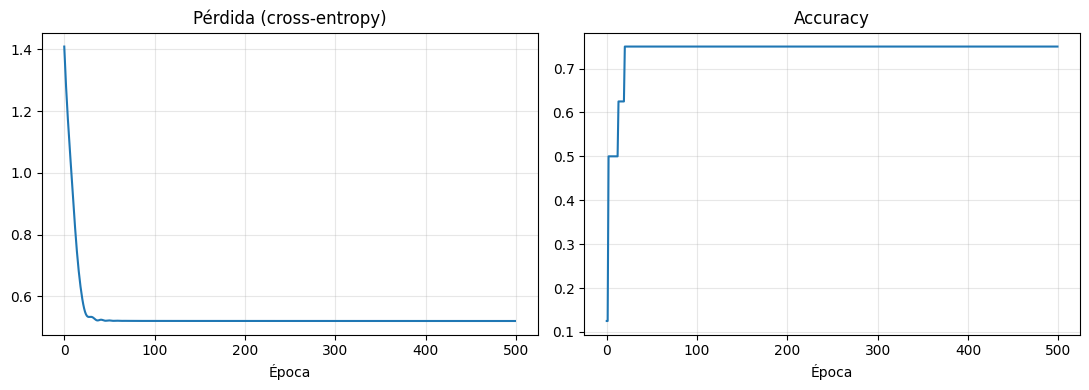

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(historia.history['loss'])
axes[0].set_title("Pérdida (cross-entropy)")
axes[0].set_xlabel("Época")

axes[1].plot(historia.history['accuracy'])
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Época")

plt.tight_layout()
plt.show()


## 9 — Verificar que la red predice bien

Antes de mirar los embeddings, comprobemos que la red aprendió a predecir el **contexto** dado el **centro**. Le pasamos cada input y vemos qué probabilidad asignó a cada palabra del vocabulario.


In [11]:
probs = modelo_w2v.predict(X, verbose=0)

print(f"{'input':>10s}  →  {'esperado':>10s}  | distribución softmax")
for (entrada, salida), p in zip(pares, probs):
    distribucion = "  ".join(
        f"{idx2palabra[i]}={p[i]:.2f}" for i in range(n_vocab)
    )
    pred = idx2palabra[int(np.argmax(p))]
    marca = "✓" if pred == salida else "✗"
    print(f"{entrada:>10s}  →  {salida:>10s}  {marca}  {distribucion}")


     input  →    esperado  | distribución softmax
        no  →       puedo  ✓  no=0.00  pagar=0.00  puedo=1.00  transferir=0.00
     puedo  →          no  ✓  no=0.50  pagar=0.25  puedo=0.00  transferir=0.25
     puedo  →       pagar  ✗  no=0.50  pagar=0.25  puedo=0.00  transferir=0.25
     pagar  →       puedo  ✓  no=0.00  pagar=0.00  puedo=1.00  transferir=0.00
        no  →       puedo  ✓  no=0.00  pagar=0.00  puedo=1.00  transferir=0.00
     puedo  →          no  ✓  no=0.50  pagar=0.25  puedo=0.00  transferir=0.25
     puedo  →  transferir  ✗  no=0.50  pagar=0.25  puedo=0.00  transferir=0.25
transferir  →       puedo  ✓  no=0.00  pagar=0.00  puedo=1.00  transferir=0.00


Fíjate en la fila donde la entrada es `puedo`: la red predice **mitad y mitad** entre `pagar` y `transferir`, porque las dos son respuestas válidas en distintas frases. Eso es exactamente lo que esperábamos — la red **aprendió que ambas palabras son intercambiables en ese contexto**, y por eso sus embeddings van a quedar parecidos.


## 10 — Extraer los embeddings

Los **pesos de la capa `embedding`** son la matriz de `4 × 2`: cada fila es el vector de una palabra.


In [12]:
W_emb = modelo_w2v.get_layer("embedding").get_weights()[0]

print("Shape de la matriz de embeddings:", W_emb.shape)
print("\nEmbeddings aprendidos:")
print(f"{'palabra':>12s}  {'dim_1':>8s}  {'dim_2':>8s}")
for palabra in vocabulario:
    v = W_emb[palabra2idx[palabra]]
    print(f"{palabra:>12s}  {v[0]:8.3f}  {v[1]:8.3f}")


Shape de la matriz de embeddings: (4, 2)

Embeddings aprendidos:
     palabra     dim_1     dim_2
          no     1.874     1.766
       pagar     1.013     2.409
       puedo    -1.971    -0.982
  transferir     2.636     0.881


## 11 — Visualizar los embeddings en el plano

Como cada palabra tiene exactamente 2 números, podemos graficarlas como puntos. Si Word2Vec funcionó, **`pagar` y `transferir` deberían quedar cerca** entre sí, y separadas de `no` y `puedo`.


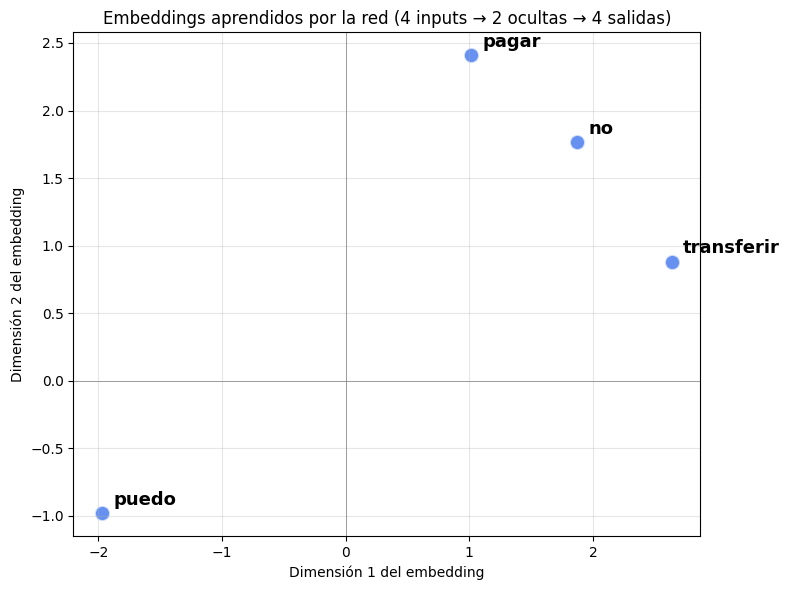

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(W_emb[:, 0], W_emb[:, 1], s=120, c="#2563EB", alpha=0.7, edgecolors='white', linewidths=1.5)
for palabra, idx in palabra2idx.items():
    x, y_ = W_emb[idx]
    ax.annotate(palabra, (x, y_), xytext=(8, 6), textcoords='offset points', fontsize=13, fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel("Dimensión 1 del embedding")
ax.set_ylabel("Dimensión 2 del embedding")
ax.set_title("Embeddings aprendidos por la red (4 inputs → 2 ocultas → 4 salidas)")
plt.tight_layout()
plt.show()


## 12 — Medir la similitud con distancia coseno

Cuando los embeddings tienen 2 dimensiones podemos verlos en una gráfica. Pero con 100 o 300 dimensiones no se puede dibujar nada — necesitamos una **medida numérica** de qué tan parecidas son dos palabras.

La métrica estándar es la **similitud coseno**: el coseno del ángulo entre los dos vectores. Va de `-1` (opuestos) a `+1` (idénticos en dirección), pasando por `0` (perpendiculares).

$$
\text{cos}(u, v) = \frac{u \cdot v}{\|u\| \, \|v\|}
$$


In [14]:
def similitud_coseno(u, v):
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-9))

def vec(palabra):
    return W_emb[palabra2idx[palabra]]

pares_a_comparar = [
    ("pagar", "transferir"),   # esperamos ALTA similitud (mismo contexto)
    ("no", "puedo"),           # también aparecen juntas
    ("pagar", "no"),           # esperamos BAJA similitud
    ("transferir", "puedo"),
]

print(f"{'par':>30s}    sim_coseno")
for p1, p2 in pares_a_comparar:
    sim = similitud_coseno(vec(p1), vec(p2))
    print(f"  ({p1!r}, {p2!r}):".ljust(32), f"{sim:+.3f}")


                           par    sim_coseno
  ('pagar', 'transferir'):       +0.660
  ('no', 'puedo'):               -0.957
  ('pagar', 'no'):               +0.914
  ('transferir', 'puedo'):       -0.990


**Lectura:** la similitud coseno mide el **ángulo entre dos vectores**, no su distancia:

- `+1` → vectores apuntan en la **misma dirección** (máxima similitud)
- `0` → **perpendiculares** (sin relación)
- `-1` → apuntan en **dirección opuesta** (anti-similitud)

Por eso puede salir negativo: `-0.795` significa que los dos vectores apuntan hacia lados casi opuestos del plano (ángulo ≈ 143°).

**Aviso sobre este ejemplo de juguete:** con Skip-gram, `pagar` y `transferir` **sí entran como centro** (predicen `puedo`), así que sus embeddings ya no quedan “congelados” como antes. Aun así, con **solo 2 frases** y **8 pares** los resultados pueden ser inestables: un re-entrenamiento puede dar cosenos distintos.

**¿Qué falta respecto a Word2Vec en producción?**

- **Dos matrices** de embeddings (`W_in` para el centro, `W_out` para el contexto) — `gensim` lo hace así.
- **Negative sampling** en lugar de softmax completo sobre millones de palabras (Parte 2).
- **Más texto** — en la Parte 3 verás embeddings más estables con 50 frases y `window=2`.

Con eso cerramos la parte 1: vimos **a mano** Skip-gram con la misma red Keras. Ahora los detalles que lo hacen viable a escala.


# Parte 2 — Los dos detalles que hacen viable a Word2Vec


## 13 — CBOW vs Skip-gram

En las partes 1 y 3 ya implementamos **Skip-gram**: centro → contexto, con ventana configurable. El Word2Vec original (Mikolov, 2013) también define **CBOW**, la variante inversa:

| Variante | Qué predice | Intuición |
|---|---|---|
| **Skip-gram** (lo que hicimos) | Dada la palabra del **centro** → predice cada palabra del **contexto** | "¿Qué vecinas rodean a esta palabra?" |
| **CBOW** (Continuous Bag-of-Words) | Dado el **contexto** (palabras alrededor) → predice la palabra del **centro** | "Adivina la palabra que falta en el hueco" |

Por ejemplo, con `"el cliente no puede pagar"` y ventana 2 alrededor de `puede`:

- **Skip-gram** (nuestro notebook): `puede` → `el`, `cliente`, `no`, `pagar` (un softmax por par).
- **CBOW**: promediar embeddings de `["el", "cliente", "no", "pagar"]` → predecir `puede`.

**¿Cuál usar?**

- **CBOW** entrena más rápido y funciona bien con palabras frecuentes.
- **Skip-gram** captura mejor palabras raras (más ejemplos por palabra centro).

En `gensim`: `sg=1` (Skip-gram, como aquí) o `sg=0` (CBOW). El notebook 10 entrena ambos.


## 14 — Negative sampling: el truco que hace viable Word2Vec

Hay un problema gigante con la red que entrenamos: la **capa de salida tiene un softmax sobre todo el vocabulario**. Con 4 palabras es trivial; con **3 millones de palabras** (Wikipedia) sería catastrófico — cada paso de entrenamiento tendría que normalizar 3 millones de exponenciales.

**Negative sampling** lo resuelve así: en cada paso, en vez de actualizar los pesos para *todas* las palabras del vocabulario, **sólo actualiza los pesos de**:

- la **palabra correcta** (positivo) que queremos que la red prediga, y
- un **puñado de palabras aleatorias** (negativos) que queremos que NO prediga (típicamente entre 2 y 20).

El objetivo se reformula como: "subir la probabilidad del par correcto y bajar la probabilidad de unos cuantos pares aleatorios". Así, en vez de actualizar 600 millones de pesos por paso, actualizas un par de cientos.

Es la magia que permitió a Word2Vec entrenar sobre Wikipedia entera en horas, no semanas.


# Parte 3 — Skip-gram con un corpus mediano

Repetimos la **misma red Skip-gram** de la parte 1, pero sobre **50 frases** de soporte de una app financiera y con **`window=2`** (más contexto por palabra centro). Así vas a poder:

- Cambiar la **dimensión del embedding** (3, 10, 50, 100…) y ver cómo afecta la calidad.
- Decidir si meter **capas ocultas extra** entre el embedding y la salida (más abajo te explico cuándo conviene y cuándo no).
- Ver el espacio de embeddings en **3D interactivo con Plotly**, agrupado por temas.

El corpus tiene cinco temas: pagos/tarjetas, transferencias, acceso/sesión, cuenta/saldo y fraude/soporte. Si todo sale bien, los embeddings deberían **agruparse por tema**.


## 15 — El corpus mediano (50 frases de soporte fintech)


In [15]:
corpus_grande = [
    # --- Pagos y tarjetas (10) ---
    "el cliente realiza un pago con tarjeta",
    "el pago con tarjeta se procesa correctamente",
    "mi tarjeta funciona en cualquier comercio",
    "el comercio rechaza mi tarjeta de débito",
    "necesito cambiar mi tarjeta vencida",
    "el banco emite una nueva tarjeta digital",
    "el pago con qr es rápido y seguro",
    "la app muestra el comprobante del pago",
    "el sistema rechaza mi tarjeta de crédito",
    "quiero asociar mi tarjeta a la app",

    # --- Transferencias (10) ---
    "la transferencia bancaria se procesa rápido",
    "el banco aprueba la transferencia del cliente",
    "el cliente solicita una transferencia urgente",
    "la transferencia llegó al destinatario rápido",
    "necesito guardar el comprobante de transferencia",
    "la app permite enviar dinero al exterior",
    "el tipo de cambio favorece mi transferencia",
    "no puedo transferir dinero a mi amigo",
    "solicito hacer una transferencia internacional",
    "la transferencia tarda más de lo esperado",

    # --- Acceso y sesión (10) ---
    "el usuario inicia sesión en el banco",
    "no puedo iniciar sesión en la app",
    "no puedo acceder a mi cuenta",
    "el cliente cambia su contraseña",
    "el usuario verifica su identidad biométrica",
    "la app pide reconocimiento facial",
    "el banco envía un código de verificación",
    "el sistema solicita confirmar el acceso",
    "necesito recuperar mi contraseña olvidada",
    "la app cierra mi sesión automáticamente",

    # --- Cuenta y saldo (10) ---
    "el usuario revisa el saldo de su cuenta",
    "mi saldo aparece incorrecto en la app",
    "necesito actualizar mis datos personales",
    "el cliente consulta su historial crediticio",
    "quiero abrir una cuenta de ahorro",
    "necesito cerrar mi cuenta corriente",
    "el banco ofrece intereses competitivos para ahorrar",
    "el saldo de mi cuenta se actualiza diariamente",
    "la cuenta muestra todos mis movimientos recientes",
    "necesito ver mi estado de cuenta mensual",

    # --- Fraude y soporte (10) ---
    "mi tarjeta fue clonada esta mañana",
    "el banco congela mi cuenta por seguridad",
    "el cargo es desconocido en mi estado",
    "solicito reembolso del cargo duplicado",
    "necesito contactar al servicio de soporte",
    "el agente resuelve mi problema rápido",
    "quiero reportar un cargo no autorizado",
    "el banco detecta fraude en mi cuenta",
    "necesito desbloquear mi tarjeta robada",
    "la app no funciona correctamente hoy",
]

frases_tok_grande = [f.lower().split() for f in corpus_grande]
print(f"Total de oraciones: {len(frases_tok_grande)}")
print(f"Palabras totales:   {sum(len(f) for f in frases_tok_grande)}")
print(f"Vocabulario único:  {len({w for f in frases_tok_grande for w in f})}")


Total de oraciones: 50
Palabras totales:   319
Vocabulario único:  144


## 16 — Preparar X y y a partir del corpus grande

Igual que en la parte 1: vocabulario, pares Skip-gram `(centro, contexto)` con `pares_skipgram`, y one-hots. Aquí usamos **`WINDOW_GRANDE = 2`** (hasta 2 palabras a cada lado del centro).


In [16]:
# Vocabulario del corpus grande
vocab_g = sorted({w for f in frases_tok_grande for w in f})
n_vocab_g = len(vocab_g)
p2i = {p: i for i, p in enumerate(vocab_g)}
i2p = {i: p for p, i in p2i.items()}

WINDOW_GRANDE = 2  # Skip-gram: hasta 2 palabras de contexto a cada lado

pares_g = []
for tokens in frases_tok_grande:
    pares_g.extend(pares_skipgram(tokens, window=WINDOW_GRANDE))

# Matrices de entrenamiento (reutilizamos one_hot y pares_skipgram de la parte 1)
X_g = np.array([one_hot(p2i[p_in], n_vocab_g) for p_in, _ in pares_g])
y_g = np.array([p2i[p_out] for _, p_out in pares_g], dtype=np.int32)

print(f"Tamaño del vocabulario: {n_vocab_g}")
print(f"Skip-gram (window={WINDOW_GRANDE}) — pares de entrenamiento: {len(pares_g)}")
print(f"X_g shape: {X_g.shape}    y_g shape: {y_g.shape}")


Tamaño del vocabulario: 144
Skip-gram (window=2) — pares de entrenamiento: 976
X_g shape: (976, 144)    y_g shape: (976,)


## 17 — ¿Vale meter más capas ocultas?

**Sí se vale, pero tiene un matiz importante.**

### Word2Vec "puro" es deliberadamente **superficial**

La arquitectura original de Word2Vec tiene **una sola capa intermedia** (el embedding) y una capa de salida con softmax. Es así a propósito por dos razones:

1. **El embedding ES el modelo.** Al final lo que nos interesa son **las filas de la matriz de embeddings**, no la red completa. La red de salida es una excusa para tener algo que entrenar; una vez entrenado, tiramos la salida y nos quedamos sólo con el embedding.
2. **Velocidad.** Word2Vec se diseñó para entrenarse sobre corpus de **miles de millones** de palabras. Entre menos capas, más rápido.

### Si metes más capas ocultas, ya no es Word2Vec — es un mini language model

Cuando agregas, por ejemplo, una capa `Dense(64, ReLU)` entre el embedding y la softmax, lo que tienes es un **modelo de lenguaje feed-forward** chiquito. Eso:

- **A veces ayuda**: con corpus chicos y tareas más complejas (ej. modelar mejor relaciones no lineales entre embeddings).
- **A veces estorba**: añade parámetros que con corpus pequeño llevan al **sobreajuste**, y como el embedding ya no es la única cosa "que aprende", su geometría puede deteriorarse.

### Hiperparámetros que sí vale la pena mover

Más impactantes que añadir capas:

- **`dim_embedding`** (la dimensión del embedding). Más dimensiones = más capacidad para capturar matices semánticos. 50-300 es lo típico.
- **`epochs`**: con corpus chico hace falta entrenar muchas épocas (cientos).
- **`learning_rate`**: 0.01 es razonable para Adam con datos chicos.
- El **tamaño del corpus** y el **window size** son los factores que más mueven la calidad real en Word2Vec.

### Recomendación práctica

- Empieza **sin capas ocultas extra** (el Word2Vec clásico).
- Después prueba a meter una `Dense(32, ReLU)` y compara visualmente los clusters. ¿Mejoran o empeoran?
- Evita meter 2 o 3 capas — con 50 frases nada más, garantía de overfitting.


## 18 — Construir el modelo

Igual que en la parte 1, pero ahora:

- La capa de entrada tiene `n_vocab_g` posiciones (una por cada palabra del corpus).
- La capa de embedding ya no tiene 2 neuronas — usamos **50** para tener más capacidad de capturar relaciones semánticas. Puedes cambiar este número directamente en el código (probar 3, 10, 50, 100…) y volver a correr.
- La salida sigue siendo softmax sobre todo el vocabulario.

Si quieres meter una capa oculta extra (ver sección 17), basta con descomentar la línea `layers.Dense(...)` que dejé como ejemplo en el código.


In [17]:
tf.keras.utils.set_random_seed(0)

modelo_g = keras.Sequential(
    [
        layers.Input(shape=(n_vocab_g,), name="entrada_one_hot"),
        layers.Dense(50, activation="linear", use_bias=False, name="embedding"),
        # layers.Dense(32, activation="relu", name="oculta_extra"),  # opcional: capa oculta extra
        layers.Dense(n_vocab_g, activation="softmax", name="prob_siguiente"),
    ],
    name="w2v_grande",
)

modelo_g.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


## 19 — Entrenar el modelo

Con 50 frases las épocas son rápidas. Si la pérdida se atora muy alta, suban `epochs` o el `learning_rate` directamente en el código.


Pérdida final:   2.3246
Accuracy final:  0.116


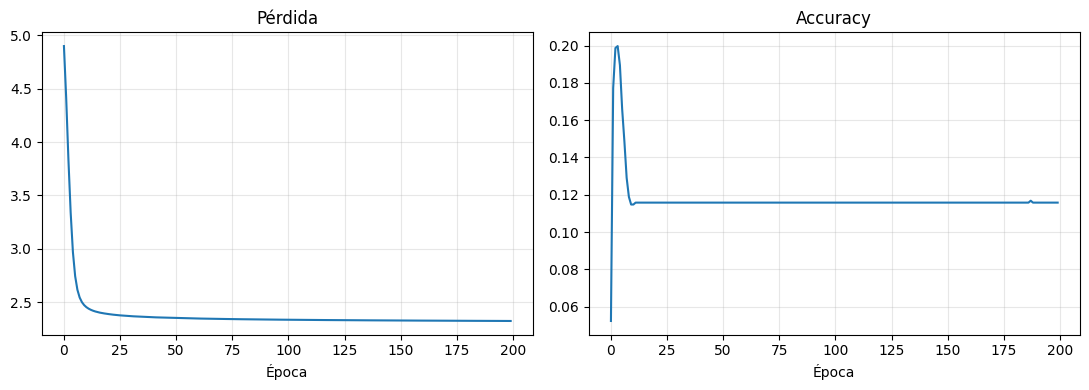

In [18]:
historia_g = modelo_g.fit(
    X_g, y_g,
    epochs=200,
    batch_size=32,
    verbose=0,
)

print(f"Pérdida final:   {historia_g.history['loss'][-1]:.4f}")
print(f"Accuracy final:  {historia_g.history['accuracy'][-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(historia_g.history['loss'])
axes[0].set_title("Pérdida")
axes[0].set_xlabel("Época")
axes[1].plot(historia_g.history['accuracy'])
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Época")
plt.tight_layout()
plt.show()


**Sobre el accuracy:** no esperes que llegue a 1.0. Predecir una palabra de contexto exacta es **inherentemente ambigua** — después de `el` pueden venir muchas palabras válidas. Lo que importa es que la pérdida baje y los embeddings emerjan con estructura.


## 20 — Extraer los embeddings

Igual que en la parte 1: los pesos de la capa `embedding` son la matriz `n_vocab × 50`. Cada fila es el vector de una palabra.


In [19]:
W_emb_g = modelo_g.get_layer("embedding").get_weights()[0]
print(f"Matriz de embeddings: shape = {W_emb_g.shape}")
print(f"  ({W_emb_g.shape[0]} palabras × {W_emb_g.shape[1]} dimensiones)")


Matriz de embeddings: shape = (144, 50)
  (144 palabras × 50 dimensiones)


## 21 — Buscar palabras parecidas con coseno

Definimos una función equivalente al `most_similar` de gensim: para una palabra dada, calcula la similitud coseno con todas las demás y devuelve las más cercanas.


In [20]:
def similitud_coseno(u, v):
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-9))

def mas_parecidas(palabra, top_k=5):
    if palabra not in p2i:
        print(f"'{palabra}' no está en el vocabulario")
        return
    v = W_emb_g[p2i[palabra]]
    sims = []
    for otra, idx in p2i.items():
        if otra == palabra:
            continue
        sims.append((otra, similitud_coseno(W_emb_g[idx], v)))
    sims.sort(key=lambda x: -x[1])
    print(f"Más parecidas a '{palabra}':")
    for w, s in sims[:top_k]:
        print(f"  {w:>18s}   sim = {s:+.3f}")

mas_parecidas("pago")


Más parecidas a 'pago':
                 con   sim = +0.481
             guardar   sim = +0.473
                  qr   sim = +0.441
             rechaza   sim = +0.414
                  es   sim = +0.404


In [21]:
mas_parecidas("transferencia")


Más parecidas a 'transferencia':
            solicito   sim = +0.430
              cambio   sim = +0.423
               tarda   sim = +0.407
               llegó   sim = +0.321
              cierra   sim = +0.316


In [22]:
mas_parecidas("tarjeta")


Más parecidas a 'tarjeta':
               amigo   sim = +0.445
       correctamente   sim = +0.310
            comercio   sim = +0.309
              cambio   sim = +0.292
              quiero   sim = +0.285


In [23]:
mas_parecidas("cuenta")


Más parecidas a 'cuenta':
         diariamente   sim = +0.414
            esperado   sim = +0.408
                 por   sim = +0.391
              estado   sim = +0.347
             aparece   sim = +0.344


## 22 — Visualizar el espacio en **3D interactivo** con Plotly

Los embeddings tienen 50 dimensiones. Para verlos, los proyectamos a **3D con PCA** y los graficamos con **Plotly**, así pueden **rotar, hacer zoom y pasar el mouse** sobre cada palabra. Los colores marcan cinco temas; si los embeddings funcionan, deberían formar **regiones agrupadas** por color.


In [24]:
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# Mapeo palabra → tema (palabras no listadas quedan como "común")
TEMAS = {
    "pagos":          {"pago", "tarjeta", "comercio", "qr", "débito", "crédito",
                       "comprobante", "asociar", "vencida", "digital", "emite", "rechaza"},
    "transferencias": {"transferencia", "transferir", "destinatario", "exterior",
                       "internacional", "bancaria", "cambio", "dinero", "tipo",
                       "favorece", "tarda", "esperado"},
    "acceso":         {"sesión", "contraseña", "iniciar", "acceder", "biométrica",
                       "facial", "código", "verificación", "identidad", "reconocimiento",
                       "recuperar", "olvidada", "cierra", "automáticamente", "acceso",
                       "confirmar"},
    "cuenta":         {"saldo", "cuenta", "ahorro", "corriente", "movimientos",
                       "historial", "crediticio", "estado", "mensual", "intereses",
                       "competitivos", "ahorrar", "diariamente", "datos", "personales",
                       "actualiza", "actualizar"},
    "fraude":         {"clonada", "fraude", "congela", "robada", "sospechoso",
                       "desbloquear", "reembolso", "duplicado", "autorizado", "reportar",
                       "desconocido", "cargo", "soporte", "agente", "seguridad"},
}
COLORES = {
    "pagos":          "#2563EB",   # azul
    "transferencias": "#16A34A",   # verde
    "acceso":         "#DC2626",   # rojo
    "cuenta":         "#9333EA",   # morado
    "fraude":         "#EA580C",   # naranja
    "común":          "#9CA3AF",   # gris
}

def tema_de(palabra):
    for tema, vocab in TEMAS.items():
        if palabra in vocab:
            return tema
    return "común"

# Proyección a 3D con PCA
pca3d = PCA(n_components=3, random_state=42)
proy3d = pca3d.fit_transform(W_emb_g)

# Una traza por tema, para que la leyenda sea clickeable
fig = go.Figure()
for tema, color in COLORES.items():
    indices = [i for i, p in enumerate(vocab_g) if tema_de(p) == tema]
    if not indices:
        continue
    fig.add_trace(go.Scatter3d(
        x=proy3d[indices, 0],
        y=proy3d[indices, 1],
        z=proy3d[indices, 2],
        mode='markers+text',
        marker=dict(size=5, color=color, opacity=0.85, line=dict(width=0.5, color='white')),
        text=[vocab_g[i] for i in indices],
        textposition='top center',
        textfont=dict(size=9),
        name=tema,
        hovertemplate="<b>%{text}</b><br>tema: " + tema + "<extra></extra>",
    ))

fig.update_layout(
    title="Embeddings (50 dim) proyectados a 3D con PCA",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
    ),
    width=950, height=750,
    margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(itemsizing='constant'),
)
fig.show()


**Cómo interpretar el gráfico:**

- **Rota** la nube con el ratón — los clusters que parecen mezclados de un ángulo pueden estar bien separados desde otro.
- Click en una etiqueta de la **leyenda** para ocultar/mostrar un tema y comparar.
- Pasa el mouse sobre un punto para ver palabra y tema.
- Las palabras "comunes" (gris: `el`, `la`, `mi`, `de`, etc.) probablemente queden mezcladas en el centro porque aparecen en todos los temas.

**Cosas que pueden experimentar (volver a la celda del modelo y cambiar a mano):**

1. Cambia `Dense(50, ...)` a `Dense(3, ...)` y vuelve a entrenar — verás los embeddings tal cual, sin proyección PCA. Los clusters se ven peor (3 dimensiones es poco para 144 palabras).
2. Sube a `Dense(100, ...)` — ¿los clusters quedan más definidos?
3. Descomenta la línea `layers.Dense(32, activation="relu", ...)` para meter una capa oculta extra. ¿Mejora algo o se desordena el espacio?
4. Sube `epochs` a 500 — ¿se ven clusters más apretados o ya se sobreentrenó?
5. Cambia `WINDOW_GRANDE` a `1` o `5` en la celda 16 y vuelve a armar `pares_g` — ¿cuántos pares genera y cómo cambian los clusters?


# 23 — Cierre

Recorrimos Word2Vec de tres formas:

1. **A mano con Keras** (parte 1): red mínima + **Skip-gram** (`window=1`). Vimos cómo nacen los embeddings al predecir el contexto desde el centro.
2. **Conceptual** (parte 2): CBOW (alternativa a Skip-gram) y negative sampling (viable a escala).
3. **Corpus mediano** (parte 3): mismas 50 frases fintech con Skip-gram `window=2`, embeddings configurables, coseno y PCA 3D con Plotly.

**Ideas clave para llevarse:**

- Los embeddings **no se programan**, **emergen** de entrenar una red en una tarea muy simple (predecir palabras vecinas).
- Palabras que aparecen en **contextos similares** terminan con **vectores similares**.
- Word2Vec **clásico es superficial a propósito** — el embedding es el resultado, no una capa intermedia. Meter más capas convierte a la red en un mini language model y suele empeorar la calidad de los embeddings cuando hay pocos datos.
- Los hiperparámetros que más mueven la calidad son: **tamaño del corpus**, **dimensión del embedding**, **window size** y **épocas**.
- Word2Vec es la base conceptual de cosas más modernas como **GloVe**, **fastText** y, eventualmente, los embeddings contextuales de **BERT** y los **transformers**.


# 24 — Qué nos falta y hacia dónde va esto

Word2Vec fue un salto enorme respecto a TF-IDF y one-hot, pero si lo miramos con honestidad, **estamos limitados** en varias cosas. Las limitaciones son justo las que abrieron la puerta a todo lo que vino después (BERT, GPT, los LLMs).

## Limitación 1 — Sólo representamos **palabras sueltas**, no frases ni párrafos

Word2Vec da un vector por palabra, punto. Si quieres representar una frase como `"no puedo pagar mi recibo"`, lo único que sabes hacer es **promediar los 5 vectores** (o sumarlos). Eso pierde un montón:

- **Pierde el orden**: `"el perro mordió al hombre"` y `"el hombre mordió al perro"` darían el MISMO vector promedio. Para nosotros son cosas muy distintas.
- **Pierde la composición**: el significado de "no puedo" no es simplemente `(no + puedo) / 2` — la palabra "no" cambia el sentido completo, no es un promedio.
- **Pierde el contexto**: la palabra `banco` significa cosas distintas en `"el banco me cobró"` vs `"me senté en el banco"`. Word2Vec le asigna **un solo vector**, idéntico en ambos casos.

Hacia dónde se fue la cosa: **embeddings contextuales** (ELMo, BERT) que generan **un vector distinto para la misma palabra según la frase** en la que aparezca. Y para frases enteras: **sentence transformers** que entrenan directamente un vector por oración o párrafo.

## Limitación 2 — La **distancia coseno** no captura todo

Coseno mide qué tan parecida es la dirección de dos vectores, pero:

- **No captura relaciones complejas** como negación o causa-efecto. `"feliz"` y `"triste"` pueden tener coseno alto porque aparecen en contextos parecidos (frases sobre emociones), aunque sean opuestas.
- **No es transitivo**: `A` parecido a `B` y `B` parecido a `C` no implica que `A` y `C` sean parecidos.
- **Es plano, no jerárquico**: `"perro"` y `"animal"` quedan a una distancia, pero no sabemos si uno es **subtipo** del otro.

Hacia dónde se fue: modelos que aprenden **representaciones jerárquicas** (Poincaré embeddings para taxonomías), **mecanismos de atención** que dejan al modelo aprender qué pares relacionar dinámicamente, y métricas más ricas que solo coseno.

## Limitación 3 — El modelo es **estático**

Una vez entrenado el Word2Vec sobre Wikipedia, los embeddings son fijos. Si mañana aparece la palabra `"chatgpt"`, no la conoce. Y si quieres adaptarlo a un dominio nuevo (biomedicina, fintech, código), tienes que reentrenarlo desde cero o desde un checkpoint.

Hacia dónde se fue: modelos **pre-entrenados grandes** que se pueden **fine-tunear** rápido sobre cualquier dominio sin perder el conocimiento general.

## ¿Qué nos hace falta para mejorar? Las **scaling laws**

Aquí entra una de las observaciones más importantes de los últimos años en deep learning. Resulta que la calidad de un modelo de lenguaje mejora de forma **predecible** cuando aumentas tres cosas a la vez:

1. **Más datos** (más texto para entrenar).
2. **Más cómputo** (más GPUs, más tiempo de entrenamiento).
3. **Más parámetros** (modelos más grandes).

OpenAI publicó en 2020 las "scaling laws" mostrando que **estas tres cosas siguen una relación de potencia**: si subes datos × 10, cómputo × 10 y parámetros × 10, la pérdida del modelo baja en una cantidad predecible. **No hay magia, hay escala.**

Esto explica por qué pasamos de Word2Vec (300 dimensiones, miles de millones de palabras) a GPT-4 (cientos de miles de millones de parámetros, billones de tokens). Pero no es solo "echarle más leña al fuego": el **cambio de arquitectura** (de redes superficiales a transformers profundos) **destrabó** la posibilidad de seguir escalando — los transformers se beneficiaron mucho más de los datos extra y el cómputo extra que las arquitecturas anteriores. Word2Vec se "satura" rápido cuando le metes más datos; un transformer no.

## El camino que viene en este curso

Lo que vamos a ver más adelante hereda directamente de Word2Vec:

- **Embeddings preentrenados** (`fastText`, `GloVe`) que mejoran lo que vimos pero siguen siendo estáticos.
- **Atención y transformers**: el bloque de construcción que reemplazó a las redes recurrentes y abrió la era de los LLMs.
- **BERT, GPT y modelos contextuales**: cada palabra obtiene un embedding distinto según su contexto.
- **Embeddings de oraciones y documentos**: para tareas como búsqueda semántica, RAG y clasificación de texto largo.
- **LLMs e instrucciones**: cómo pasamos de predecir palabras vecinas (Skip-gram, como en este notebook) a modelos que conversan, razonan y siguen instrucciones complejas.

Lo bonito es que **la idea raíz es la misma** que vimos hoy: entrenar una red para predecir palabras y, en el proceso, hacer que aprenda representaciones útiles del lenguaje. Lo que cambia es la escala — más datos, más cómputo, más parámetros — y la arquitectura que permite aprovechar esa escala.
